In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

seed = 0
np.random.seed(seed)

# Parameters for the fake planet generation
slope = 1.4624e-04  # R_Earth/K - from the rad_cliff_completeness_correction.ipynb fits derived from median
slope = 4.0e-04  # random
intercept = 1.6782   # R_Earth - from the rad_cliff_completeness_correction.ipynb fits
intercept = 1   #random
sigma = 1       # Standard deviation of Gaussian scatter in R_Earth
skew_a = 5       # Skew strength for radius distribution (positive = right-skew)

# Temperature grid
n_planets_per_bin = 100  # Number of planets per temperature bin
temp_min = 3000
temp_max = 7000
temp_step = 500
temp_bin_edges = np.arange(temp_min, temp_max + temp_step, temp_step)
temp_centers = (temp_bin_edges[:-1] + temp_bin_edges[1:]) / 2

# Generate fake planets
fake_planets = []
delta = skew_a / np.sqrt(1 + skew_a**2)
skew_mean_shift = sigma * delta * np.sqrt(2 / np.pi)

for temp in temp_centers:
    # Mean radius at this temperature
    mean_radius = slope * temp + intercept
    
    # Shift loc so the skew-normal mean matches the linear trend
    loc = mean_radius - skew_mean_shift
    radii = skewnorm.rvs(a=skew_a, loc=loc, scale=sigma, size=n_planets_per_bin)
    
    # Add some temperature scatter within the bin
    temps = np.random.uniform(temp - temp_step / 2, temp + temp_step / 2, n_planets_per_bin)
    
    for t, r in zip(temps, radii):
        fake_planets.append({'st_teff': t, 'pl_rade': r})

# Create DataFrame
fake_planets_df = pd.DataFrame(fake_planets)

# Filter to keep only planets in the 2-4 R_Earth range
fake_planets_df = fake_planets_df[(fake_planets_df['pl_rade'] >= 1.50) & 
                                   (fake_planets_df['pl_rade'] <= 4.0)]

print(f"Generated {len(fake_planets_df)} fake planets")
print(f"Temperature range: {fake_planets_df['st_teff'].min():.0f} - {fake_planets_df['st_teff'].max():.0f} K")
print(f"Radius range: {fake_planets_df['pl_rade'].min():.2f} - {fake_planets_df['pl_rade'].max():.2f} R_Earth")
print(f"\nLinear trend: Radius = {slope:.4e} * Teff + {intercept:.2f}")

fake_planets_df.head(10)


Generated 718 fake planets
Temperature range: 3006 - 7000 K
Radius range: 1.52 - 4.00 R_Earth

Linear trend: Radius = 4.0000e-04 * Teff + 1.00


,st_teff,pl_rade
0,3480.968189,3.616722
1,3146.073763,1.645679
2,3120.414390,2.228179
3,3050.146971,3.905101
4,3008.214815,3.118833
5,3464.764658,2.094734
6,3334.958273,2.368131
7,3392.576456,1.812616
9,3293.205083,2.210588
10,3031.977633,2.025115


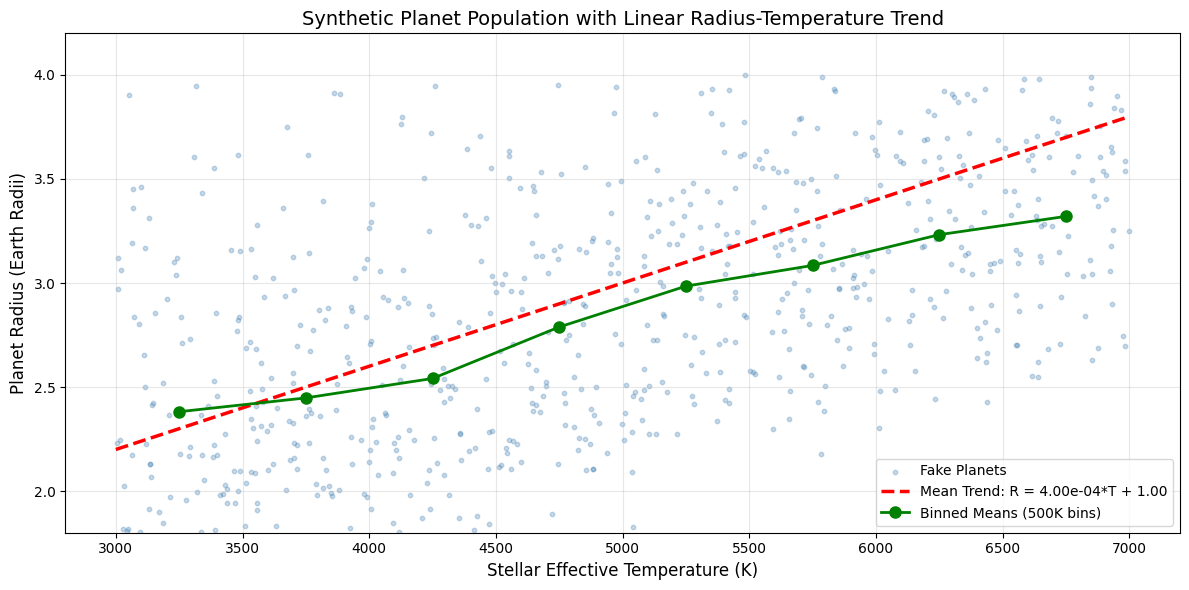


Binned mean radii:
  3250 K: 2.382 R_Earth
  3750 K: 2.448 R_Earth
  4250 K: 2.541 R_Earth
  4750 K: 2.789 R_Earth
  5250 K: 2.985 R_Earth
  5750 K: 3.085 R_Earth
  6250 K: 3.232 R_Earth
  6750 K: 3.320 R_Earth


In [157]:
# Visualize the fake planet distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot of all fake planets
ax.scatter(fake_planets_df['st_teff'], fake_planets_df['pl_rade'], 
           alpha=0.3, s=10, color='steelblue', label='Fake Planets')

# Plot the underlying trend line
temp_line = np.linspace(temp_min, temp_max, 100)
radius_line = slope * temp_line + intercept
ax.plot(temp_line, radius_line, 'r--', linewidth=2.5, 
        label=f'Mean Trend: R = {slope:.2e}*T + {intercept:.2f}')

# Calculate and plot binned means
temp_bin_edges = np.arange(temp_min, temp_max + temp_step, temp_step)
temp_bin_centers = []
mean_radii = []

for i in range(len(temp_bin_edges)-1):
    mask = (fake_planets_df['st_teff'] >= temp_bin_edges[i]) & \
           (fake_planets_df['st_teff'] < temp_bin_edges[i+1])
    if mask.sum() > 0:
        temp_bin_centers.append((temp_bin_edges[i] + temp_bin_edges[i+1]) / 2)
        mean_radii.append(fake_planets_df.loc[mask, 'pl_rade'].mean())

ax.plot(temp_bin_centers, mean_radii, 'go-', linewidth=2, markersize=8,
        label='Binned Means (500K bins)')

ax.set_xlabel('Stellar Effective Temperature (K)', fontsize=12)
ax.set_ylabel('Planet Radius (Earth Radii)', fontsize=12)
ax.set_title('Synthetic Planet Population with Linear Radius-Temperature Trend', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(2800, 7200)
ax.set_ylim(1.8, 4.2)

plt.tight_layout()
plt.show()

print(f"\nBinned mean radii:")
for temp, rad in zip(temp_bin_centers, mean_radii):
    print(f"  {temp:.0f} K: {rad:.3f} R_Earth")


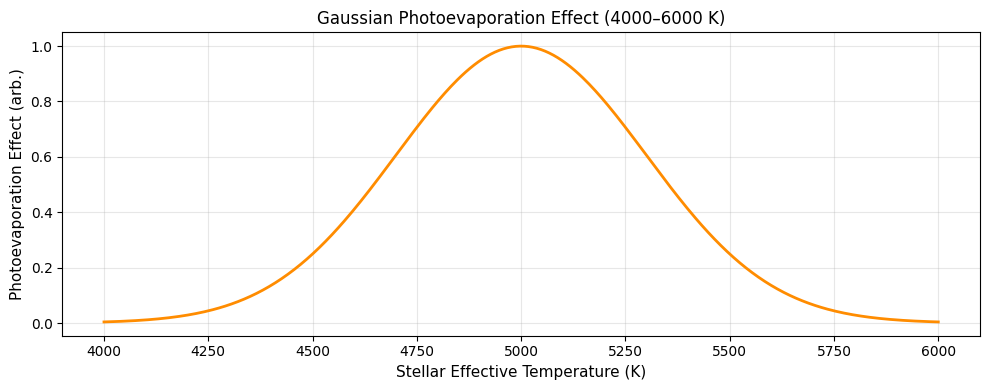

In [158]:
# Gaussian photoevaporation effect across 4000–6000 K
photoevaporation_teff = np.linspace(4000, 6000, 400)
photoevaporation_effect = np.exp(-0.5 * ((photoevaporation_teff - 5000) / 300.0) ** 2)

photoevaporation_effect[:5], photoevaporation_effect.max()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(photoevaporation_teff, photoevaporation_effect, color="darkorange", linewidth=2)
ax.set_xlabel("Stellar Effective Temperature (K)", fontsize=11)
ax.set_ylabel("Photoevaporation Effect (arb.)", fontsize=11)
ax.set_title("Gaussian Photoevaporation Effect (4000–6000 K)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [159]:
# Apply photoevaporation in a separate step
photo_center = 5500
photo_sigma = 500
photo_peak = 1.0
photo_reduction = 0.9

fake_planets_df_photo = fake_planets_df.copy()

for i in range(len(temp_bin_edges) - 1):
    mask = (fake_planets_df_photo['st_teff'] >= temp_bin_edges[i]) & \
           (fake_planets_df_photo['st_teff'] < temp_bin_edges[i + 1])
    n_in_bin = mask.sum()
    if n_in_bin == 0:
        continue
    temp_center = 0.5 * (temp_bin_edges[i] + temp_bin_edges[i + 1])
    photo_frac = photo_peak * np.exp(-0.5 * ((temp_center - photo_center) / photo_sigma) ** 2)
    affected = np.random.random(n_in_bin) < photo_frac
    fake_planets_df_photo.loc[mask, 'pl_rade'] *= np.where(affected, photo_reduction, 1.0)

print(f"Applied photoevaporation to {len(fake_planets_df_photo)} planets")
print(f"Radius range after photoevaporation: {fake_planets_df_photo['pl_rade'].min():.2f} - {fake_planets_df_photo['pl_rade'].max():.2f} R_Earth")


Applied photoevaporation to 718 planets
Radius range after photoevaporation: 1.52 - 3.99 R_Earth


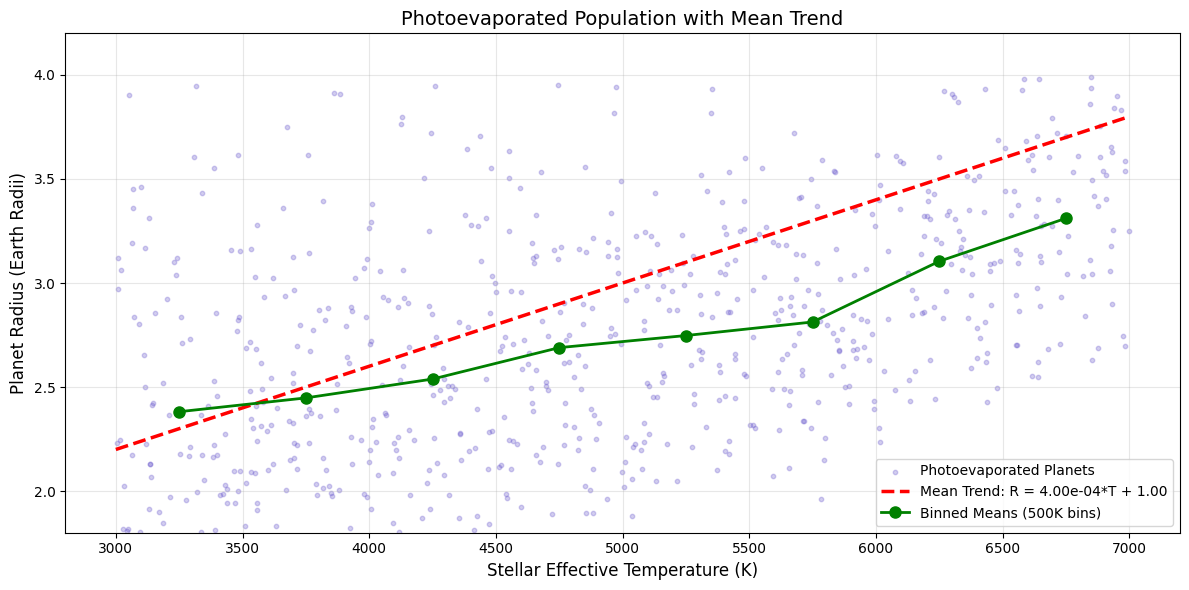


Binned mean radii (photoevaporated):
  3250 K: 2.382 R_Earth
  3750 K: 2.448 R_Earth
  4250 K: 2.539 R_Earth
  4750 K: 2.690 R_Earth
  5250 K: 2.748 R_Earth
  5750 K: 2.813 R_Earth
  6250 K: 3.105 R_Earth
  6750 K: 3.311 R_Earth


In [160]:
# Plot photoevaporated planets and binned means
fig, ax = plt.subplots(figsize=(12, 6))


ax.scatter(fake_planets_df_photo['st_teff'], fake_planets_df_photo['pl_rade'],
           alpha=0.3, s=10, color='slateblue', label='Photoevaporated Planets')

temp_line = np.linspace(temp_min, temp_max, 100)
radius_line = slope * temp_line + intercept
ax.plot(temp_line, radius_line, 'r--', linewidth=2.5,
        label=f'Mean Trend: R = {slope:.2e}*T + {intercept:.2f}')

temp_bin_edges = np.arange(temp_min, temp_max + temp_step, temp_step)
temp_bin_centers = []
mean_radii_photo = []

for i in range(len(temp_bin_edges)-1):
    mask = (fake_planets_df_photo['st_teff'] >= temp_bin_edges[i]) & \
           (fake_planets_df_photo['st_teff'] < temp_bin_edges[i+1])
    if mask.sum() > 0:
        temp_bin_centers.append((temp_bin_edges[i] + temp_bin_edges[i+1]) / 2)
        mean_radii_photo.append(fake_planets_df_photo.loc[mask, 'pl_rade'].mean())

ax.plot(temp_bin_centers, mean_radii_photo, 'go-', linewidth=2, markersize=8,
        label='Binned Means (500K bins)')

ax.set_xlabel('Stellar Effective Temperature (K)', fontsize=12)
ax.set_ylabel('Planet Radius (Earth Radii)', fontsize=12)
ax.set_title('Photoevaporated Population with Mean Trend', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(2800, 7200)
ax.set_ylim(1.8, 4.2)

plt.tight_layout()
plt.show()

print(f"\nBinned mean radii (photoevaporated):")
for temp, rad in zip(temp_bin_centers, mean_radii_photo):
    print(f"  {temp:.0f} K: {rad:.3f} R_Earth")
